# GTSOM Tutorial: General Topology Learning on Synthetic Blobs

## Beyond the grid: data-driven output topology

The companion tutorial, *GTSOM Tutorial: Mapping MNIST Handwritten Digits*, trains a SOM on a fixed hexagonal grid (`GTSOM.from_grid`). That grid is chosen up front by the user — its shape, size, and connectivity are decided before training begins and have nothing to do with the structure of the data itself.

GTSOM's namesake feature is the ability to do without that fixed grid entirely. Instead of a regular lattice, the **output space topology can be derived directly from the data**: prototype positions are projected into a low-dimensional embedding (via PCA, Laplacian Eigenmaps, or a random projection), and the neuron adjacency graph is then built from those projected positions using a proximity graph — a Delaunay triangulation or a Gabriel graph. This tutorial demonstrates that workflow (`GTSOM.from_data`) on a synthetic dataset designed to make the resulting topology easy to see and interpret.

### What we will do

1. Generate 5 well-separated Gaussian blobs in 10 dimensions (N=5,000)
2. Initialize a 100-prototype GTSOM with a data-driven topology, using PCA for prototype coordinates and a Gabriel graph for adjacency
3. Train and inspect the learned map
4. Discuss what the Gabriel graph is, how it relates to a Delaunay triangulation, and when you might prefer one over the other

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from gtsom import GTSOM

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 2. Generating the Data

We use `sklearn.datasets.make_blobs` to generate 5 isotropic Gaussian clusters in 10 dimensions, with 5,000 total samples (1,000 per cluster) and unit standard deviation within each cluster. In 10 dimensions, even moderately-spaced cluster centers produce blobs that are extremely well separated — Euclidean distances between different clusters' points grow much faster than distances within a cluster as dimensionality increases. This gives us labeled data with unambiguous ground-truth structure, which makes it easy to visually verify that GTSOM's learned topology recovers the true cluster organization.

The features are standardized (zero mean, unit variance per dimension) before training, since GTSOM performs no internal scaling of its own.

In [2]:
SEED    = 42
N       = 5_000
D       = 10
N_BLOBS = 5

X_raw, y = make_blobs(
    n_samples=N,
    n_features=D,
    centers=N_BLOBS,
    cluster_std=1.0,
    random_state=SEED,
)
print(f"Generated: {X_raw.shape}, labels: {np.unique(y)}")
print(f"Label counts: { {c: int((y==c).sum()) for c in range(N_BLOBS)} }")

scaler = StandardScaler()
X = scaler.fit_transform(X_raw).astype(np.float32)
print(f"Standardized: mean~0, std~1 per feature")

Generated: (5000, 10), labels: [0 1 2 3 4]
Label counts: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}
Standardized: mean~0, std~1 per feature


## 3. A Reference PCA Projection

Before training, it's useful to see what the data actually looks like. We compute a standalone 2-D PCA projection purely for visualization — this is *not* the same PCA that GTSOM will use internally to place prototypes; it's just a sanity check on the data's separability. GTSOM trains directly on the standardized 10-D data, not on this projection.

Reference 2-D PCA projection: variance explained = 76.0%


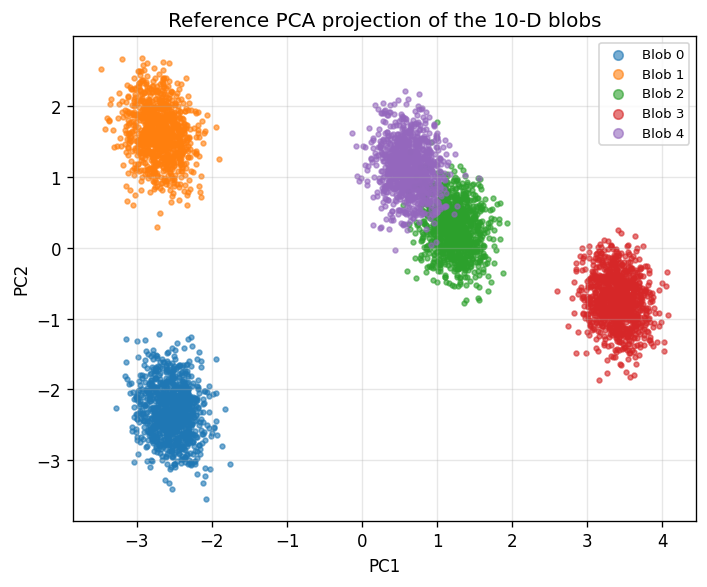

In [3]:
pca_ref = PCA(n_components=2, random_state=SEED)
Z_ref   = pca_ref.fit_transform(X)
print(f"Reference 2-D PCA projection: variance explained = "
      f"{pca_ref.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 5))
for c in range(N_BLOBS):
    mask = y == c
    ax.scatter(Z_ref[mask, 0], Z_ref[mask, 1], s=8, alpha=0.6, label=f'Blob {c}')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Reference PCA projection of the 10-D blobs')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Choosing a Data-Driven Output Topology

### From a fixed grid to a learned topology

`GTSOM.from_grid` requires choosing a lattice shape (e.g. 20×20 hex) before seeing how the data is actually structured. `GTSOM.from_data` instead builds the output topology from the data itself, in three steps:

1. **Find prototype vectors.** `M` prototypes are computed from the input data — either via k-means (`W_init='kmeans'`) or random sampling (`W_init='random'`). We use k-means here, since cluster centroids in well-separated data are a natural and efficient way to seed prototype positions.
2. **Project prototypes to low dimensions.** The `M` prototype vectors are projected into `coord_dim` dimensions (2 or 3) to define their positions in output space — the `coord_init` parameter controls how (`'pca'`, `'le'` for Laplacian Eigenmaps, `'random'`, or `'random_proj'`). We use `'pca'`, which pairs naturally with k-means prototypes since cluster centroids carry real data structure that a linear projection can faithfully summarize.
3. **Build the adjacency graph.** Once prototypes have 2-D (or 3-D) positions, `coord_topo` determines which proximity graph connects them — either a **Delaunay triangulation** or a **Gabriel graph**. This graph *is* the SOM's output space topology: it defines which prototypes are considered neighbors during training, replacing the fixed grid adjacency used by `from_grid`.

### Delaunay triangulation vs. Gabriel graph

Both are classic proximity graphs built from a set of points in the plane (or higher dimensions), and they're closely related: **the Gabriel graph is always a subgraph of the Delaunay triangulation** — every Gabriel edge is also a Delaunay edge, but not vice versa.

A **Delaunay triangulation** connects two points if there exists a circle passing through both that contains no other point in its interior. It produces a dense, fully triangulated mesh.

A **Gabriel graph** is more restrictive: two points are connected only if the circle having the segment between them *as its diameter* contains no other point. This is a stricter emptiness condition than Delaunay's (the diametric circle is always at least as large as some valid Delaunay circumcircle through the same two points), so the Gabriel graph keeps only a subset of Delaunay edges — typically the "more locally meaningful" ones, discarding long edges that cut across sparse regions even when they happen to satisfy the looser Delaunay condition. Despite being sparser, the Gabriel graph is guaranteed to remain connected for any finite point set in general position, so it never fragments into isolated components.

In practice: Delaunay gives denser connectivity and more redundant neighborhood paths; Gabriel gives a sparser graph that more closely tracks local proximity. `gtsom` supports both via `coord_topo='delaunay'` or `coord_topo='gabriel'`. This tutorial uses **Gabriel**, since with 5 tightly separated clusters it produces a visually cleaner result — exactly one or two "bridge" edges between each pair of nearby clusters, rather than the denser web of inter-cluster triangles a Delaunay triangulation would add.

## 5. Initializing the GTSOM

We initialize with `M=100` prototypes — roughly 50 data points per prototype on average, comparable in density to the MNIST tutorial's 25 points/neuron. `nbr_topo_alpha_0` and `nbr_topo_alpha_f` control a separate, independent feature: a blend between pure output-space (graph) neighborhoods and input-space (Euclidean) neighborhoods during training. This blending is available regardless of whether the topology comes from a grid or from data — it isn't specific to `from_data`.

In [4]:
M = 100

som = GTSOM(
    rho_0=10.0,
    rho_f=0.5,
    halflife_epochs=100,
    n_jobs=-1,
    nbr_topo_alpha_0=0.5,
    nbr_topo_alpha_f=1.0,
    random_state=SEED,
    compute_dr_metrics=True,
    proto_topo='STK_CADJ',
)
som.from_data(
    X,
    M=M,
    coord_dim=2,
    coord_init='pca',
    W_init='kmeans',
    coord_topo='gabriel',
    labels=y,
)
print(som)
print(f"Empty RFs at init: {(som.recaller.RFSize == 0).sum()} / {som.M}")

Running FAISS k-means with 100 clusters (niter=20, nredo=1)...
K-means complete. Final MQE: 0.276727
Fitting complete using kmeans method.
GTSOM(M=100, d=10, embed_dim=2, fitted=False, age=0, snapshots=1, backend='numba', n_jobs=16, nbr_influence_min=0.01, proto_topo='STK_CADJ', alpha_schedule=ExponentialAnneal(initial=0.5, final=1.0, tau=200), compute_dr_metrics=True, train_time=0.000s)
Empty RFs at init: 0 / 100


At initialization, prototypes are seeded by k-means on the standardized data, so the initial map already reflects the cluster structure reasonably well — quite different from the MNIST tutorial, where random initialization left the lattice completely disorganized at age 0. This is expected: k-means itself is already finding the same 5 clusters that the SOM will go on to organize topologically.

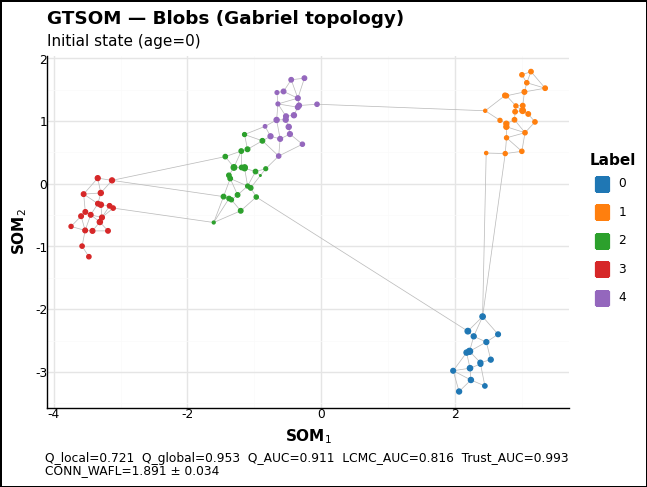

In [5]:
g = som.plot(
    color_by='labels',
    title='GTSOM — Blobs (Gabriel topology)',
    subtitle='Initial state (age=0)',
)
g.draw()

## 6. Training

We train for 200 epochs using the same exponential bandwidth decay schedule structure as the MNIST tutorial (see that notebook for a full explanation of `rho_0`, `rho_f`, and `halflife_epochs`). A snapshot of the SOM state is captured every 20 epochs.

In [6]:
som.fit(
    X,
    n_epochs=200,
    labels=y,
    verbose=True,
    plot_every=20,
)
print()
print(som)
print(f"Empty RFs after fit: {(som.recaller.RFSize == 0).sum()} / {som.M}")

  Epoch      rho    alpha        MQE    delBMU
  -----   ------   ------   --------   -------
      1   10.0000   0.5000     2.1178    0.9396
      2   9.8513   0.5017     1.7521    0.9882
      3   9.7049   0.5035     1.7616    0.9948
      4   9.5606   0.5052     1.7798    0.9968
      5   9.4184   0.5070     1.8009    0.9566
      6   9.2784   0.5087     1.6857    0.9908
      7   9.1405   0.5105     1.7114    0.9824
      8   9.0046   0.5123     1.6740    0.9946
      9   8.8707   0.5141     1.7128    0.9452
     10   8.7388   0.5158     1.5957    0.9988
  -----   ------   ------   --------   -------
     11   8.6089   0.5176     1.5875    0.9786
     12   8.4809   0.5194     1.5434    0.9998
     13   8.3548   0.5212     1.5885    1.0000
     14   8.2306   0.5230     1.5603    1.0000
     15   8.1083   0.5249     1.6031    0.9924
     16   7.9877   0.5267     1.5469    0.9996
     17   7.8690   0.5285     1.5313    0.9952
     18   7.7520   0.5303     1.5165    0.9504
     19   7.

## 7. Learning Curves

As in the MNIST tutorial, two quantities are monitored at every epoch: global MQE (root-mean-square distance from each point to its nearest prototype) and delBMU (the proportion of points whose nearest prototype changed since the previous epoch). Because the blobs are already well-separated at initialization (thanks to k-means seeding), expect both curves to settle more quickly and with less dramatic early movement than in the MNIST tutorial, where prototypes started from random positions.

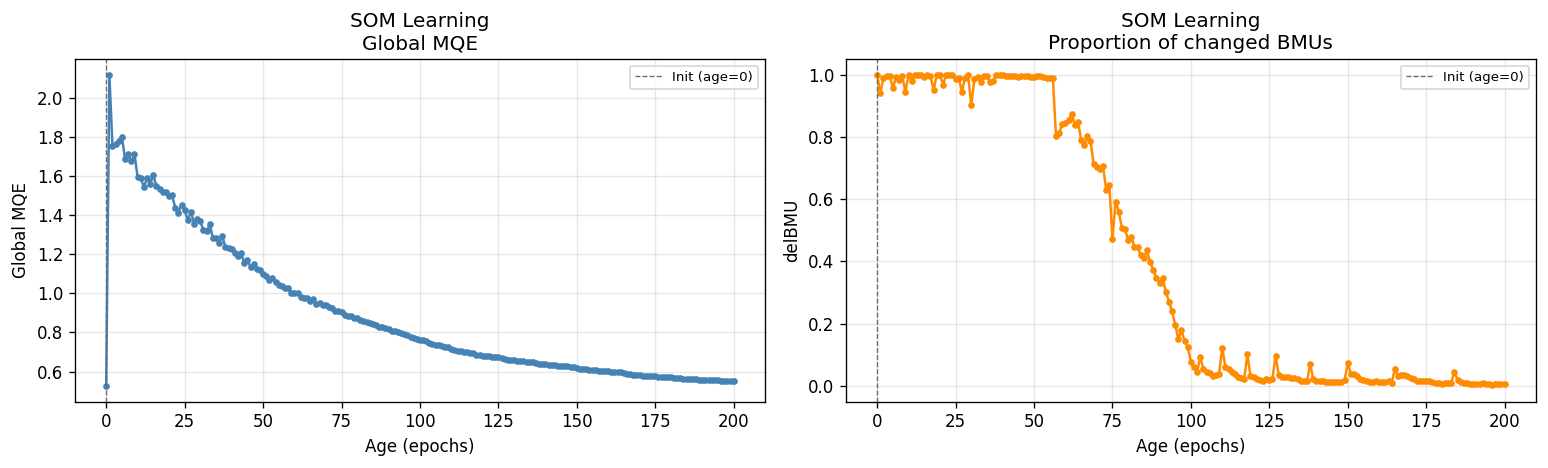

In [7]:
ages_arr   = np.array([s['age']    for s in som.learn_history_])
mqes_arr   = np.array([s['mqe']    for s in som.learn_history_])
delbmu_arr = np.array([s['delBMU'] for s in som.learn_history_])

fig, (ax_mqe, ax_del) = plt.subplots(1, 2, figsize=(13, 4))

ax_mqe.plot(ages_arr, mqes_arr, 'o-', lw=1.5, ms=3, color='steelblue')
ax_mqe.axvline(0, color='dimgrey', lw=0.8, linestyle='--', label='Init (age=0)')
ax_mqe.set_xlabel('Age (epochs)')
ax_mqe.set_ylabel('Global MQE')
ax_mqe.set_title('SOM Learning\nGlobal MQE')
ax_mqe.legend(fontsize=8)
ax_mqe.grid(True, alpha=0.3)

ax_del.plot(ages_arr, delbmu_arr, 'o-', lw=1.5, ms=3, color='darkorange')
ax_del.axvline(0, color='dimgrey', lw=0.8, linestyle='--', label='Init (age=0)')
ax_del.set_xlabel('Age (epochs)')
ax_del.set_ylabel('delBMU')
ax_del.set_title('SOM Learning\nProportion of changed BMUs')
ax_del.set_ylim(-0.05, 1.05)
ax_del.legend(fontsize=8)
ax_del.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. The Final Learned Map

The map below shows the trained SOM colored by the plurality label at each neuron. Five tight clusters should be clearly visible, each dominated by a single blob label, connected by a small number of long "bridge" edges — the Gabriel graph's minimal connections between otherwise well-separated regions.

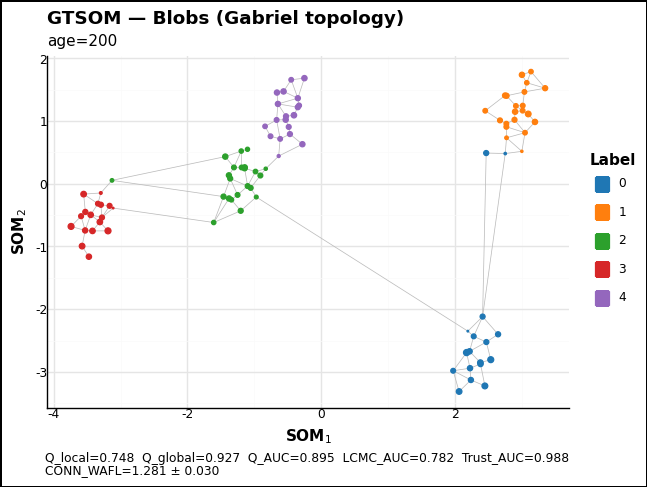

In [8]:
g = som.plot(
    color_by='labels',
    title='GTSOM — Blobs (Gabriel topology)',
    subtitle=f'age={som.age}',
)
g.draw()

### Quantization error and receptive field size

Coloring by MQE and by receptive field size gives two further diagnostic views. Within each of the 5 clusters, receptive field sizes should be fairly uniform and substantial (tens of points per prototype). A small number of prototypes — typically those that initialized into the sparse space *between* clusters rather than inside one — may show very small or even empty receptive fields. This is a structural property of fitting a data-driven topology to data with genuine gaps: a fixed grid (`from_grid`) guarantees every neuron sits inside the data cloud by construction, but a data-driven topology has no such guarantee, since prototype positions are determined by the data itself rather than fixed in advance.

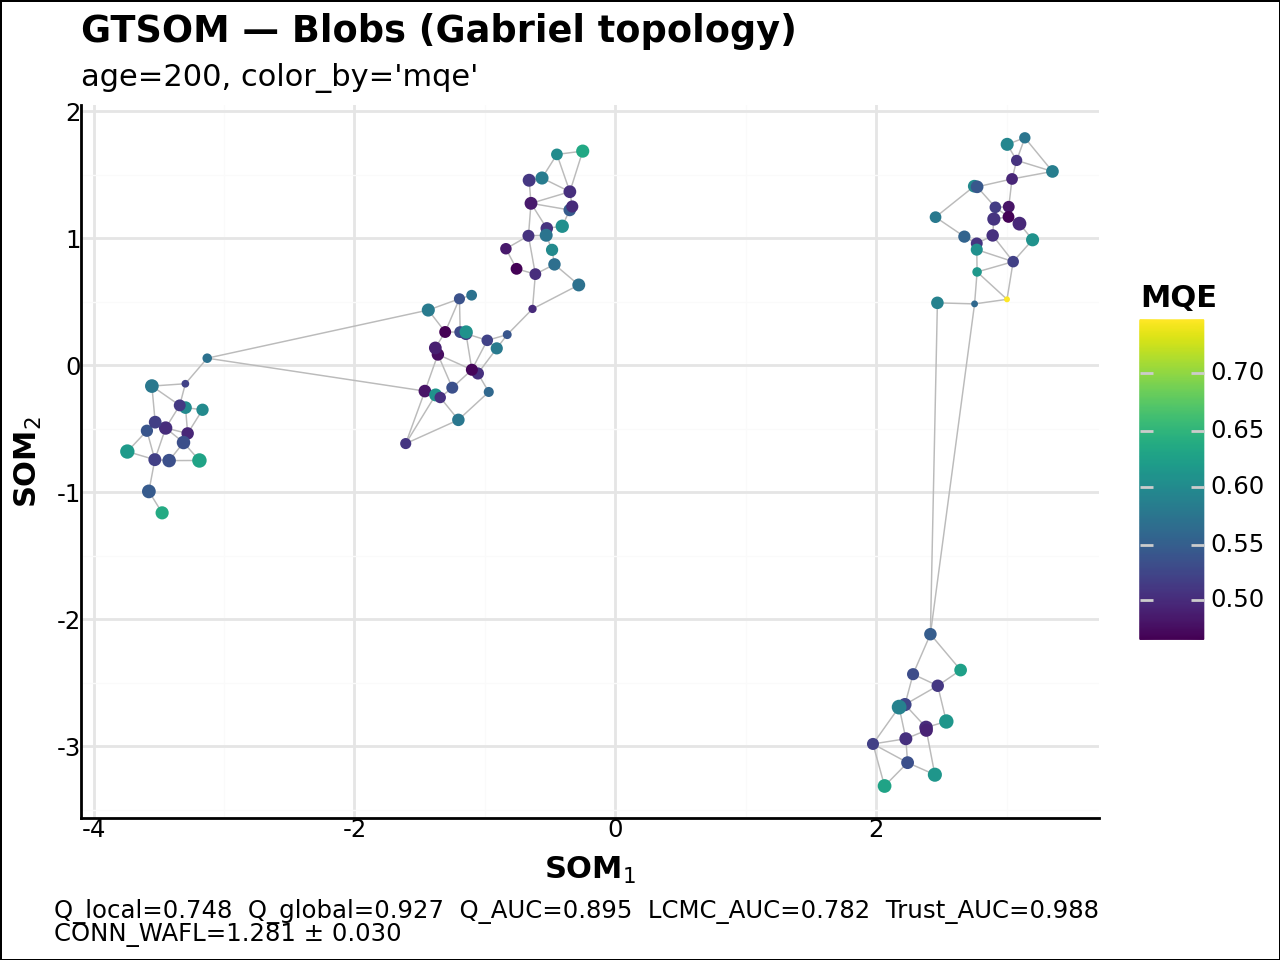

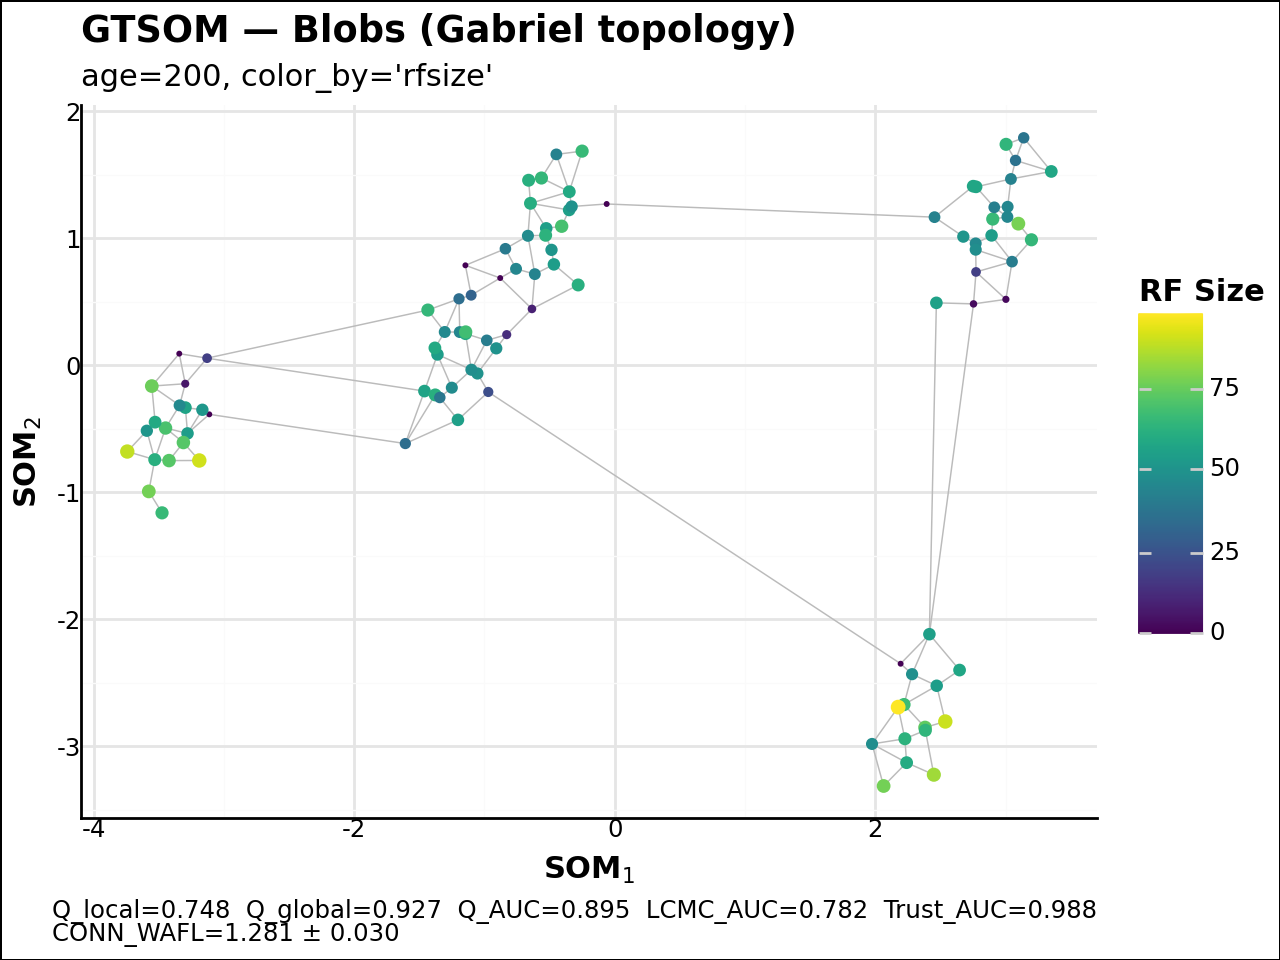

In [9]:
for color_by in ['mqe', 'rfsize']:
    g = som.plot(
        color_by=color_by,
        title='GTSOM — Blobs (Gabriel topology)',
        subtitle=f'age={som.age}, color_by={color_by!r}',
    )
    display(g)

## 9. A Quick Comparison: Delaunay Topology on the Same Data

To make the Delaunay/Gabriel distinction concrete, we re-initialize an identical GTSOM but with `coord_topo='delaunay'` instead of `'gabriel'`, using the same random seed and prototype count. Since every Gabriel edge is also a Delaunay edge, expect the Delaunay version to show all the same cluster and bridge structure as before, plus additional edges — most visibly, extra triangulated connections within each cluster and possibly more than one bridge edge between cluster pairs.

Running FAISS k-means with 100 clusters (niter=20, nredo=1)...
K-means complete. Final MQE: 0.276727
Fitting complete using kmeans method.


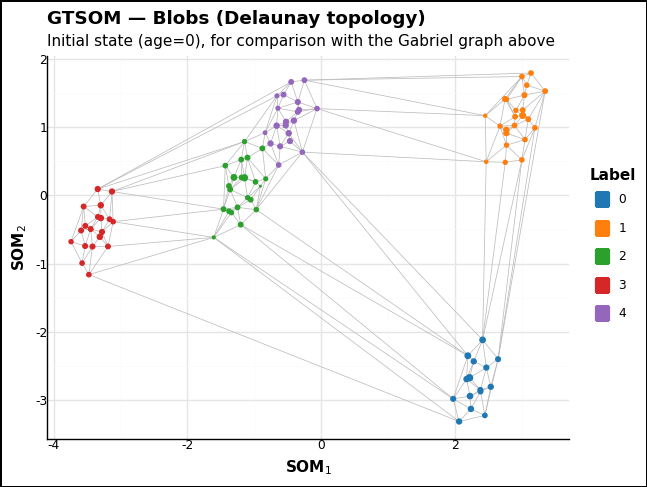

In [10]:
som_delaunay = GTSOM(
    rho_0=10.0,
    rho_f=0.5,
    halflife_epochs=100,
    n_jobs=-1,
    nbr_topo_alpha_0=0.5,
    nbr_topo_alpha_f=1.0,
    random_state=SEED,
    compute_dr_metrics=False,
    proto_topo='STK_CADJ',
)
som_delaunay.from_data(
    X,
    M=M,
    coord_dim=2,
    coord_init='pca',
    W_init='kmeans',
    coord_topo='delaunay',
    labels=y,
)

g = som_delaunay.plot(
    color_by='labels',
    title='GTSOM — Blobs (Delaunay topology)',
    subtitle='Initial state (age=0), for comparison with the Gabriel graph above',
)
g.draw()

## 10. Summary

In this tutorial we trained a 100-prototype GTSOM on 5,000 synthetic data points in 10 dimensions, organized into 5 well-separated clusters, using a **data-driven output topology** built from a PCA projection of the prototypes and a Gabriel graph over those projected positions — `GTSOM`'s namesake "general topology" capability, as opposed to the fixed hexagonal grid used in the MNIST tutorial.

Key parameters and their roles:

| Parameter | Value | Role |
|-----------|-------|------|
| `M` | 100 | Number of prototypes; ~50 points/prototype on average |
| `coord_init` | `'pca'` | Projects prototype vectors to 2-D for output-space positions |
| `W_init` | `'kmeans'` | Prototypes seeded via k-means on the standardized data |
| `coord_topo` | `'gabriel'` | Output topology = Gabriel graph of the projected prototype positions |
| `rho_0`, `rho_f`, `halflife_epochs` | 10.0, 0.5, 100 | Neighborhood bandwidth schedule (see MNIST tutorial) |
| `n_epochs` | 200 | Total training epochs |

The Gabriel graph and Delaunay triangulation are both proximity graphs derived from a set of points; the Gabriel graph is always a subgraph of the Delaunay triangulation, retaining a sparser set of "more locally meaningful" connections while remaining guaranteed to stay connected. `gtsom` supports both via the `coord_topo` parameter of `GTSOM.from_data`.

### Next steps

- **3-D output embeddings**: `coord_dim=3` produces a 3-D output topology instead of 2-D, useful when the data's intrinsic structure doesn't compress well into a plane.
- **Laplacian Eigenmaps**: `coord_init='le'` uses a nonlinear embedding instead of PCA, which can better capture curved or non-linear cluster manifolds at the cost of more computation.
- **Real-world data**: the MNIST tutorial (`GTSOM.from_grid`) and this tutorial (`GTSOM.from_data`) together cover both of GTSOM's topology construction paths — try combining a data-driven topology with a real, messier dataset to see how the Gabriel/Delaunay graph adapts to less artificially clean cluster structure.